In [25]:
import os 
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import plotly.graph_objects as go

from pathlib import Path 

ROOT = Path.cwd().parents[1] 
EMBED_PATH = ROOT / "data/embeddings/pretrained" 
EMBED_NAME = EMBED_PATH.stem 

IMAGE_DIR = ROOT / "images/stats" / EMBED_NAME 
RESULTS_DIR = ROOT / "data/results" / EMBED_NAME

In [26]:
os.makedirs(IMAGE_DIR, exist_ok=True)

In [27]:
mal_aurocs = pd.read_csv(RESULTS_DIR / "aurocs.csv", index_col=0)["mal_aurocs"] 

cls_cluster = pd.read_csv(RESULTS_DIR / "cluster_results.csv", index_col=0) 
patch_cluster = pd.read_csv(RESULTS_DIR / "patch_embed_summary.csv", index_col=0)

defect_coverage = (
    pd.read_csv("../../data/results/data_analysis/defect_coverage_stats.csv")
    [["category", "mean"]]
    .set_index("category")
    .rename(columns={"mean": "Defect Coverage"})
)

display_names = {
    "silhouette": "Silhouette",
    "davies_bouldin": "Davies-Bouldin",
    "cal_har": "Calinski-Harabasz",
    "normal_inter": "Normal Inter Dist.",
    "defect_inter": "Defect Inter Dist.",
    "separation": "Separation Ratio",
    "normal_intra": "Normal Intra Dist.",
    "defect_intra": "Defect Intra Dist.",
    "train_intra": "Train Intra Dist.",
    "intra_ratio": "Intra Ratio",
}

cls_cluster = cls_cluster.rename(
    index=display_names,
    columns=display_names,
)

patch_cluster = patch_cluster.rename(
    index=display_names,
    columns=display_names
)

mal_aurocs = mal_aurocs.rename("AUROC")

In [28]:
combined = defect_coverage.join(mal_aurocs)

# Rename if necessary
combined = combined.rename(columns={
    "mal_aurocs": "AUROC",
})

plot_df = combined.reset_index(names="category")
no_screw = plot_df[plot_df["category"] != "screw"]


# --- All categories ---
fig = px.scatter(
    plot_df,
    x="Defect Coverage",
    y="AUROC",
    text="category",
    hover_name="category",
    trendline="ols",
)

r_all = plot_df["Defect Coverage"].corr(plot_df["AUROC"])

results_all = px.get_trendline_results(fig)
fit_all = results_all.iloc[0]["px_fit_results"]
r2_all = fit_all.rsquared

fig.data[0].showlegend = False
fig.data[1].line.color = "red"
fig.data[1].name = (
    f"All categories: r = {r_all:.3f}, R² = {r2_all:.3f}"
)
fig.data[1].showlegend = True


# Excluding screw
fig_no_screw = px.scatter(
    no_screw,
    x="Defect Coverage",
    y="AUROC",
    trendline="ols",
)

r_no_screw = no_screw["Defect Coverage"].corr(no_screw["AUROC"])

results_no_screw = px.get_trendline_results(fig_no_screw)
fit_no_screw = results_no_screw.iloc[0]["px_fit_results"]
r2_no_screw = fit_no_screw.rsquared

# Grab only the trendline from the temporary figure
no_screw_line = fig_no_screw.data[1]

no_screw_line.line.color = "blue"
no_screw_line.line.dash = "dash"
no_screw_line.name = (
    f"Excluding screw: r = {r_no_screw:.3f}, "
    f"R² = {r2_no_screw:.3f}"
)
no_screw_line.showlegend = True

fig.add_trace(no_screw_line)


fig.update_traces(textposition="top center")

fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.25,
        xanchor="center",
        yanchor="top",
    ),
    margin=dict(b=100),
)

fig.write_image(
    IMAGE_DIR / "defect_coverage_auroc.svg",
    width=1200,
    height=450
)
fig.show()

In [29]:
combined = cls_cluster.join(mal_aurocs) 

combined

,Silhouette,Normal Inter Dist.,Defect Inter Dist.,Separation Ratio,Normal Intra Dist.,Defect Intra Dist.,Davies-Bouldin,Calinski-Harabasz,AUROC
category,,,,,,,,,
tile,0.051925,13.828683,30.462551,2.202853,13.194844,25.503618,2.151681,13.841351,1.000
zipper,0.054824,10.680494,17.839172,1.670257,10.037414,14.769583,2.255279,14.878088,0.987
toothbrush,0.010358,10.852008,19.439436,1.791322,10.421845,16.982060,2.601975,3.649014,0.972
hazelnut,0.035357,17.768284,23.515533,1.323456,16.975285,21.654016,3.417890,7.660800,0.949
wood,0.078673,21.327713,28.108612,1.317938,18.945887,23.288946,2.460468,8.035849,0.944
grid,0.075255,19.194645,22.477043,1.171006,18.273794,19.301464,2.893122,6.656239,0.983
cable,0.005631,17.824223,22.918423,1.285802,17.336468,22.108635,5.485366,4.156659,0.945
leather,0.161544,11.415674,26.463190,2.318145,9.138710,17.966806,1.505843,27.550618,1.000
metal_nut,0.008135,12.177718,15.678945,1.287511,11.461515,14.659174,3.217935,5.634620,0.983


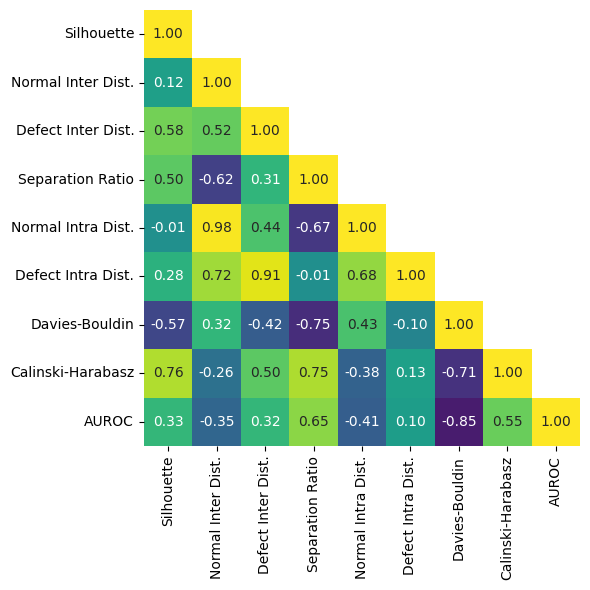

In [30]:
cor_cof = combined.corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, mask=mask, cbar=False, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_corr.svg", bbox_inches="tight")
plt.show()

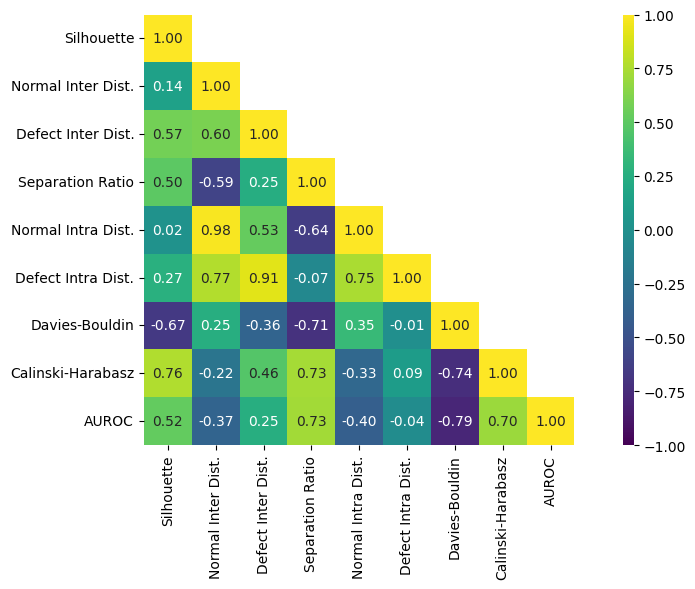

In [31]:
cor_cof = combined.drop(index="screw").corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_no_screw_corr.svg", bbox_inches="tight")
plt.show()

In [32]:
plot_df = combined.reset_index()

fig = px.scatter(
    plot_df, 
    x="Calinski-Harabasz", 
    y="AUROC", 
    text="category", 
    hover_name="category",
)

fig.data[0].showlegend = False
fig.update_traces(textposition="top center")


def add_trendline(fig, x, y, name, colour="red", dash="solid"):
    # Linear fit
    slope, intercept = np.polyfit(x, y, 1)

    # Only draw line over the range used to fit it
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept

    r = x.corr(y)
    r2 = r ** 2

    fig.add_trace(
        go.Scatter(
            x=x_line,
            y=y_line,
            mode="lines",
            line=dict(dash=dash, color=colour),
            name=f"{name}: r = {r:.3f}, R² = {r2:.3f}",
        )
    )


# 1. All categories
add_trendline(
    fig,
    plot_df["Calinski-Harabasz"],
    plot_df["AUROC"],
    "All categories",
    dash="solid",
    colour="red"
)

plot_df = plot_df[plot_df["category"] != "screw"]

# 2. Screw excluded
add_trendline(
    fig,
    plot_df["Calinski-Harabasz"],
    plot_df["AUROC"],
    "Screw excluded",
    dash="dash",
    colour="green"
)

plot_df = plot_df[plot_df["category"] != "leather"]

# 3. Screw and leather excluded
add_trendline(
    fig,
    plot_df["Calinski-Harabasz"],
    plot_df["AUROC"],
    "Screw + leather excluded",
    dash="dot",
    colour="blue"
)


fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.3,
        xanchor="center",
    ),
)

fig.show()

fig.write_image(
    IMAGE_DIR / "cls_auroc_ch_plot.svg",
    width=1200,
    height=450,
)

In [33]:
plot_df = combined.reset_index()

fig = px.scatter(
    plot_df,
    x="Davies-Bouldin",
    y="AUROC",
    text="category",
    hover_name="category",
    trendline="ols"
)

add_trendline(
    fig,
    plot_df["Davies-Bouldin"],
    plot_df["AUROC"],
    "All categories",
    dash="solid",
)

plot_df = plot_df[plot_df["category"] != "screw"]
add_trendline(
    fig,
    plot_df["Davies-Bouldin"],
    plot_df["AUROC"],
    "Screw excluded",
    dash="dash",
    colour="green"
)

fig.update_traces(textposition="top center")

fig.update_layout(
    title=None,
    legend=dict(
        x=0.425,
        y=-0.3,
        xanchor="left",
    )
)

fig.write_image(
    IMAGE_DIR / "cls_auroc_db_plot.svg",
    width=1250,
    height=450
)
fig.show()

In [34]:
patch_combined = patch_cluster.join(mal_aurocs) 

patch_combined = patch_combined.rename(
    index=display_names,
    columns=display_names,
)

patch_combined

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Normal Inter Dist.,Defect Inter Dist.,Separation Ratio,Normal Intra Dist.,Defect Intra Dist.,Train Intra Dist.,Intra Ratio,AUROC
category,,,,,,,,,,,
bottle,0.1032,2.0161,21.0375,35.5670,38.7165,1.0888,33.8505,24.6126,34.6712,0.9763,1.000
cable,0.1234,2.0764,17.4583,36.3120,42.2481,1.1644,34.2263,27.7112,35.7712,0.9568,0.945
capsule,0.1103,1.4781,8.0617,37.6489,45.1315,1.1989,37.0514,20.1856,37.4239,0.9900,0.941
carpet,0.2666,1.1308,25.0733,28.0213,44.2434,1.5799,24.8757,15.8434,25.2850,0.9838,0.980
grid,0.2727,1.1495,22.8300,29.8463,44.9653,1.5073,24.6649,16.2601,27.4793,0.8976,0.983
hazelnut,0.1479,1.4992,19.9355,39.1841,47.6354,1.2157,37.6479,23.3492,38.9374,0.9669,0.949
leather,0.2748,0.9460,14.5154,30.8956,49.6409,1.6115,26.4941,12.5874,24.4616,1.0831,1.000
metal_nut,0.0924,2.0189,31.2216,37.5273,37.4852,0.9997,34.3597,25.8242,36.5529,0.9400,0.983
pill,0.0977,1.7748,14.5052,37.9695,42.7971,1.1274,36.5540,23.9242,37.7873,0.9674,0.950


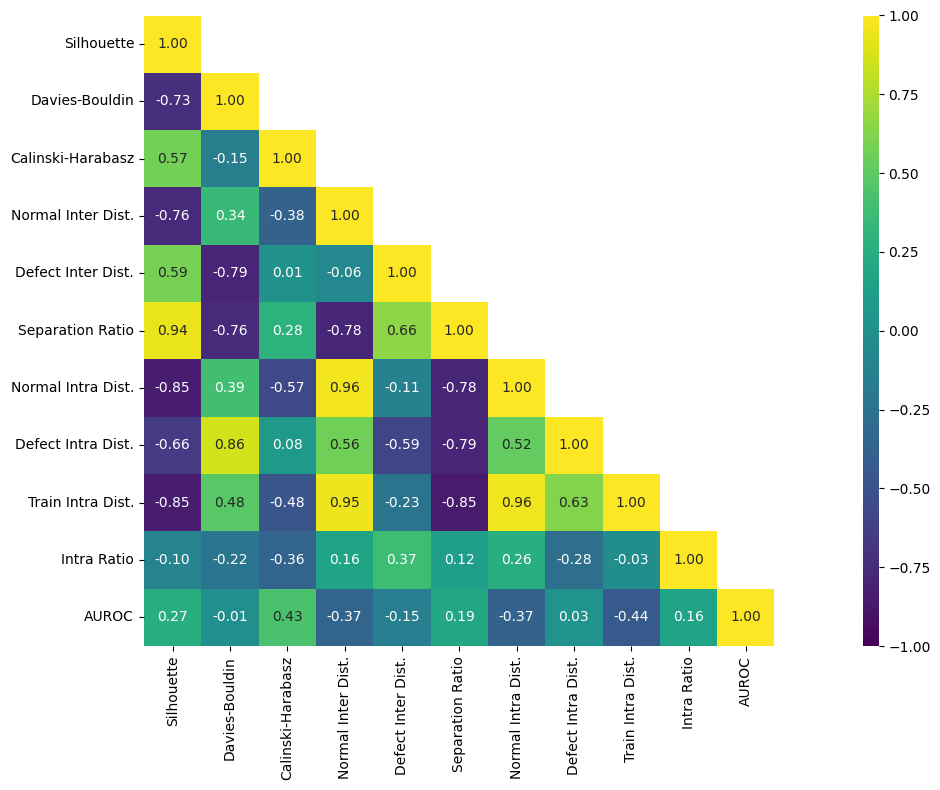

In [35]:
cor_cof = patch_combined.corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(18, 8)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/patch_corr.svg", bbox_inches="tight")
plt.show()

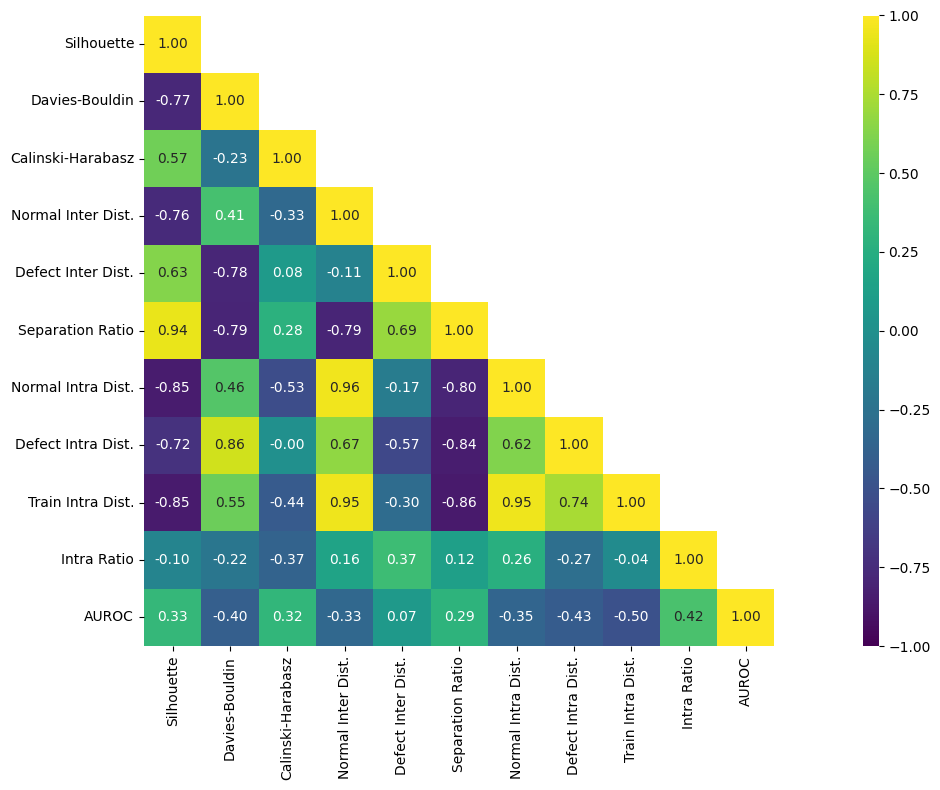

In [36]:
cor_cof = patch_combined.drop(index="screw").corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(18, 8)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/patch_no_screw_corr.svg", bbox_inches="tight")
plt.show()

In [37]:
plot_df = patch_combined.reset_index()

fig = px.scatter(
                plot_df, 
                x="Defect Intra Dist.",
                y="AUROC", 
                text="category", 
                hover_name="category", 
                trendline="ols" 
            ) 

add_trendline(
    fig,
    plot_df["Defect Intra Dist."],
    plot_df["AUROC"],
    name="All categories",
    colour="red",
    dash="solid"
)

plot_df = plot_df[plot_df["category"] != "screw"]

add_trendline(
    fig,
    plot_df["Defect Intra Dist."],
    plot_df["AUROC"],
    name="Screw excluded",
    colour="green",
    dash="dash"
)

fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.3,
        xanchor="center",
    ),
)

fig.write_image(
    IMAGE_DIR / "patch_auroc_def_intra.svg",
    width=1200,
    height=450
)
fig.show()

In [38]:
cls_pref = cls_cluster.add_prefix("CLS ")
patch_pref = patch_cluster.add_prefix("Patch ")

combined = cls_pref.join(patch_pref).join(mal_aurocs)

combined

,CLS Silhouette,CLS Normal Inter Dist.,CLS Defect Inter Dist.,CLS Separation Ratio,CLS Normal Intra Dist.,CLS Defect Intra Dist.,CLS Davies-Bouldin,CLS Calinski-Harabasz,Patch Silhouette,Patch Davies-Bouldin,Patch Calinski-Harabasz,Patch Normal Inter Dist.,Patch Defect Inter Dist.,Patch Separation Ratio,Patch Normal Intra Dist.,Patch Defect Intra Dist.,Patch Train Intra Dist.,Patch Intra Ratio,AUROC
category,,,,,,,,,,,,,,,,,,,
tile,0.051925,13.828683,30.462551,2.202853,13.194844,25.503618,2.151681,13.841351,0.2694,1.4006,56.9894,32.4100,45.3849,1.3964,25.9535,22.2262,26.6325,0.9745,1.000
zipper,0.054824,10.680494,17.839172,1.670257,10.037414,14.769583,2.255279,14.878088,0.0830,1.7521,12.1111,33.2571,37.3918,1.1236,31.2610,19.5223,32.1882,0.9712,0.987
toothbrush,0.010358,10.852008,19.439436,1.791322,10.421845,16.982060,2.601975,3.649014,0.1060,1.7726,13.9147,37.6068,43.5274,1.1573,36.3193,25.1748,37.0921,0.9792,0.972
hazelnut,0.035357,17.768284,23.515533,1.323456,16.975285,21.654016,3.417890,7.660800,0.1479,1.4992,19.9355,39.1841,47.6354,1.2157,37.6479,23.3492,38.9374,0.9669,0.949
wood,0.078673,21.327713,28.108612,1.317938,18.945887,23.288946,2.460468,8.035849,0.2768,1.4002,40.1426,30.4740,42.6916,1.4054,23.5885,20.3072,28.6674,0.8228,0.944
grid,0.075255,19.194645,22.477043,1.171006,18.273794,19.301464,2.893122,6.656239,0.2727,1.1495,22.8300,29.8463,44.9653,1.5073,24.6649,16.2601,27.4793,0.8976,0.983
cable,0.005631,17.824223,22.918423,1.285802,17.336468,22.108635,5.485366,4.156659,0.1234,2.0764,17.4583,36.3120,42.2481,1.1644,34.2263,27.7112,35.7712,0.9568,0.945
leather,0.161544,11.415674,26.463190,2.318145,9.138710,17.966806,1.505843,27.550618,0.2748,0.9460,14.5154,30.8956,49.6409,1.6115,26.4941,12.5874,24.4616,1.0831,1.000
metal_nut,0.008135,12.177718,15.678945,1.287511,11.461515,14.659174,3.217935,5.634620,0.0924,2.0189,31.2216,37.5273,37.4852,0.9997,34.3597,25.8242,36.5529,0.9400,0.983


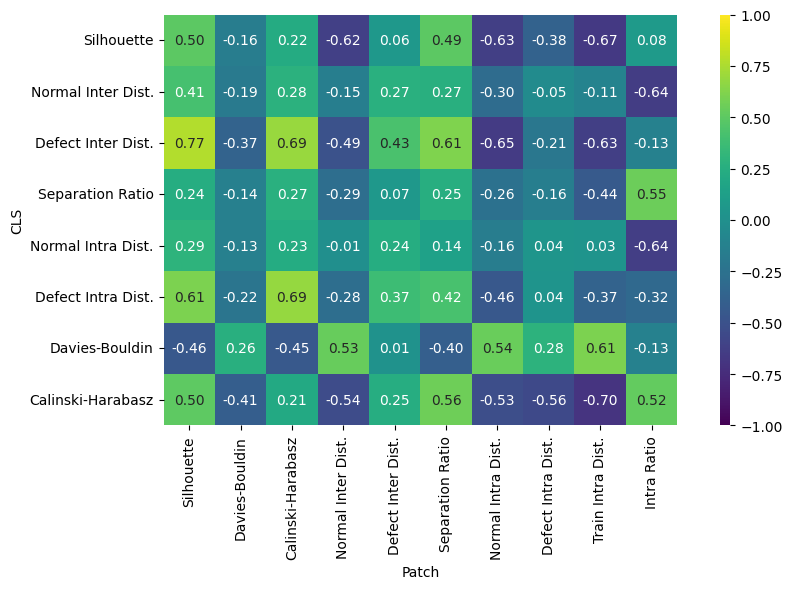

In [39]:
cls_cols = [c for c in combined.columns if c.startswith("CLS ")]
patch_cols = [c for c in combined.columns if c.startswith("Patch ")]

cor_cof = combined.corr() 
cor_cof = cor_cof.loc[cls_cols, patch_cols] 

cor_cof.index = cor_cof.index.str.removeprefix("CLS ")
cor_cof.columns = cor_cof.columns.str.removeprefix("Patch ")

cor_cof.index.name = "CLS"
cor_cof.columns.name = "Patch"

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.index, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_patch_corr.svg")
plt.show()

In [40]:
plot_df = combined.reset_index()

fig = px.scatter(
    plot_df,
    x="Patch Silhouette",
    y="CLS Defect Inter Dist.",
    text="category",
    hover_name="category",
    trendline="ols",
    color="AUROC",
    color_continuous_scale="Viridis",
    range_color=[0, 1],
)

texture_categories = [
    "carpet",
    "grid",
    "leather",
    "tile",
    "wood",
]

texture_df = combined.loc[
    combined.index.isin(texture_categories)
].copy()

object_df = combined.loc[
    ~combined.index.isin(texture_categories)
].copy()

add_trendline(
    fig,
    plot_df["Patch Silhouette"],
    plot_df["CLS Defect Inter Dist."],
    name="All categories"
)

add_trendline(
    fig,
    texture_df["Patch Silhouette"],
    texture_df["CLS Defect Inter Dist."],
    name="Uniform Categories",
    colour="green",
    dash="dash"
)

add_trendline(
    fig,
    object_df["Patch Silhouette"],
    object_df["CLS Defect Inter Dist."],
    name="Objects",
    colour="blue",
    dash="dot"
)

fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.3,
        xanchor="center",
    ),
)

fig.show()

fig.write_image(
    IMAGE_DIR / "cls_def_inter_patch_sil.svg",
    width=1200,
    height=450,
)

In [41]:
from scipy.stats import pearsonr, spearmanr

plot_df = combined.reset_index()

# Sensitivity subset
no_extremes = plot_df[
    ~plot_df["category"].isin(["wood", "leather"])
].copy()

fig = px.scatter(
    plot_df,
    x="Patch Intra Ratio",
    y="CLS Separation Ratio",
    text="category",
    hover_name="category",
    color="AUROC",
    color_continuous_scale="Viridis",
    range_color=[0, 1],
)

# All-category linear relationship
add_trendline(
    fig,
    plot_df["Patch Intra Ratio"],
    plot_df["CLS Separation Ratio"],
    name="All categories",
)

# Excluding wood and leather
add_trendline(
    fig,
    no_extremes["Patch Intra Ratio"],
    no_extremes["CLS Separation Ratio"],
    name="Excl. wood & leather",
    colour="green",
    dash="dash"
)

# Spearman checks
rho_all, p_all = spearmanr(
    plot_df["Patch Intra Ratio"],
    plot_df["CLS Separation Ratio"],
)

rho_no, p_no = spearmanr(
    no_extremes["Patch Intra Ratio"],
    no_extremes["CLS Separation Ratio"],
)

# Pearson checks as well
r_all, pearson_p_all = pearsonr(
    plot_df["Patch Intra Ratio"],
    plot_df["CLS Separation Ratio"],
)

r_no, pearson_p_no = pearsonr(
    no_extremes["Patch Intra Ratio"],
    no_extremes["CLS Separation Ratio"],
)

fig.update_traces(textposition="top center")

fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.3,
        xanchor="center",
    ),
    coloraxis_colorbar=dict(
        len=1,
        lenmode="fraction",
        y=0.5,
        yanchor="middle",
    ),
)

fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(size=0),
        name=f"Spearman all: p = {rho_all:.3f}",
        showlegend=True,
    )
)

fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(size=0),
        name=f"Spearman excl. W/L: p = {rho_no:.3f}",
        showlegend=True,
    )
)

fig.show()

fig.write_image(
    IMAGE_DIR / "cls_sep_patch_intra_ratio.svg",
    width=1200,
    height=450,
)

In [46]:
combined["Patch Intra Deviation"] = abs(
    combined["Patch Intra Ratio"] - 1
)

from scipy.stats import pearsonr, spearmanr

x = combined["Patch Intra Deviation"]
y = combined["CLS Separation Ratio"]

r, p_pearson = pearsonr(x, y)
rho, p_spearman = spearmanr(x, y)

print(f"Pearson:  r={r:.3f}, p={p_pearson:.3f}")
print(f"Spearman: rho={rho:.3f}, p={p_spearman:.3f}")

Pearson:  r=-0.252, p=0.366
Spearman: rho=-0.504, p=0.056


In [43]:
plot_df = combined.reset_index()

fig = px.scatter(
    plot_df,
    x="Patch Train Intra Dist.", 
    y="CLS Davies-Bouldin", 
    text="category", 
    hover_name="category", 
    trendline="ols", 
    color="AUROC", 
    color_continuous_scale="Viridis",
    range_color=[0,1])
 
add_trendline(
    fig,
    plot_df["Patch Train Intra Dist."],
    plot_df["CLS Davies-Bouldin"],
    name="All categories"
)

plot_df = plot_df[plot_df["category"] != "screw"]

add_trendline(
    fig,
    plot_df["Patch Train Intra Dist."],
    plot_df["CLS Davies-Bouldin"],
    name="Excluded screw",
    colour="green",
    dash="dash"
)

fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.3,
        xanchor="center",
    ),
)

fig.show() 
fig.write_image(IMAGE_DIR / "cls_db_patch_train_intra.svg",
    width=1200,
    height=450
)

In [44]:
plot_df = combined.reset_index()

fig = px.scatter(
    plot_df,
    x="Patch Train Intra Dist.", 
    y="CLS Davies-Bouldin", 
    text="category", 
    hover_name="category", 
    trendline="ols", 
    color="AUROC", 
    color_continuous_scale="Viridis",
    range_color=[0,1])
 
add_trendline(
    fig,
    plot_df["Patch Train Intra Dist."],
    plot_df["CLS Davies-Bouldin"],
    name="All categories"
)

plot_df = plot_df[plot_df["category"] != "screw"]

add_trendline(
    fig,
    plot_df["Patch Train Intra Dist."],
    plot_df["CLS Davies-Bouldin"],
    name="Excluded screw",
    colour="green",
    dash="dash"
)

fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.3,
        xanchor="center",
    ),
)

fig.show() 
fig.write_image(IMAGE_DIR / "cls_db_patch_train_intra.svg",
    width=1200,
    height=450
)

In [45]:
plot_df = combined.reset_index()

fig = px.scatter(
    plot_df,
    x="Patch Train Intra Dist.", 
    y="CLS Calinski-Harabasz", 
    text="category", 
    hover_name="category", 
    trendline="ols", 
    color="AUROC", 
    color_continuous_scale="Viridis",
    range_color=[0,1])
 
add_trendline(
    fig,
    plot_df["Patch Train Intra Dist."],
    plot_df["CLS Calinski-Harabasz"],
    name="All categories"
)

plot_df = plot_df[plot_df["category"] != "leather"]

add_trendline(
    fig,
    plot_df["Patch Train Intra Dist."],
    plot_df["CLS Calinski-Harabasz"],
    name="Excluded leather",
    colour="green",
    dash="dash"
)

fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.3,
        xanchor="center",
    ),
)

fig.show() 
fig.write_image(IMAGE_DIR / "cls_ch_patch_train_intra.svg",
    width=1200,
    height=450
)